<a href="https://colab.research.google.com/github/lenkalashreyas/CSI-Transactions-Model-Round-2-/blob/main/Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Extract the rar file into the /content/ folder
!unrar x -o+ "/content/final_dataset.rar"

# List files to confirm the .csv is there
import os
print("Extracted files:", os.listdir('/content/'))



UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/final_dataset.rar

Extracting  final_dataset.csv                                              4%  9% 13% 18% 22% 27% 32% 36% 41% 45% 50% 54% 59% 64% 68% 73% 77% 82% 86% 91% 96%100%  OK 
All OK
Extracted files: ['.config', 'final_dataset.rar', 'final_dataset.csv', 'sample_data']


In [ ]:
# 1. Print all column names to see what is actually there
print("Actual Column Names in your file:")
print(df.columns.tolist())

# 2. Automatically clean column names (removes hidden spaces)
df.columns = df.columns.str.strip()

# 3. Look at the first 2 rows to identify the 'Label' column
print("\nFirst 2 rows of data:")
display(df.head(2))

Actual Column Names in your file:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode', 'random_noise_1', 'random_noise_2']

First 2 rows of data:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,random_noise_1,random_noise_2
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0,-0.267021,37
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,-3.423886,65


In [ ]:
# 1. Drop irrelevant/noise columns
cols_to_drop = [
    'Unnamed: 0', 'cc_num', 'first', 'last', 'street',
    'trans_num', 'unix_time', 'random_noise_1', 'random_noise_2'
]
df_cleaned = df.drop(columns=cols_to_drop)

# 2. Extract useful info from Date/Time
# Converting the string 'trans_date_trans_time' into hours and months
df_cleaned['trans_date_trans_time'] = pd.to_datetime(df_cleaned['trans_date_trans_time'])
df_cleaned['hour'] = df_cleaned['trans_date_trans_time'].dt.hour
df_cleaned['day_of_week'] = df_cleaned['trans_date_trans_time'].dt.dayofweek

# 3. Handle 'dob' (Date of Birth) to get Age
df_cleaned['dob'] = pd.to_datetime(df_cleaned['dob'])
df_cleaned['age'] = (df_cleaned['trans_date_trans_time'] - df_cleaned['dob']).dt.days // 365

# Drop the original date columns now that we have the numbers
df_cleaned.drop(columns=['trans_date_trans_time', 'dob'], inplace=True)

print("Feature Selection Complete. Noise removed and time features engineered.")
df_cleaned.head()

Feature Selection Complete. Noise removed and time features engineered.


,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,merch_zipcode,hour,day_of_week,age
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,3495.0,"Psychologist, counselling",36.011293,-82.048315,0,28705.0,0,1,30
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149.0,Special educational needs teacher,49.159047,-118.186462,0,NaN,0,1,40
2,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,4154.0,Nature conservation officer,43.150704,-112.154481,0,83236.0,0,1,56
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,1939.0,Patent attorney,47.034331,-112.561071,0,NaN,0,1,52
4,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,99.0,Dance movement psychotherapist,38.674999,-78.632459,0,22844.0,0,1,32


Dataset Shape: (1296675, 26)

Missing Values: 390475

Transaction Counts:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentage of Fraud: 0.5789%


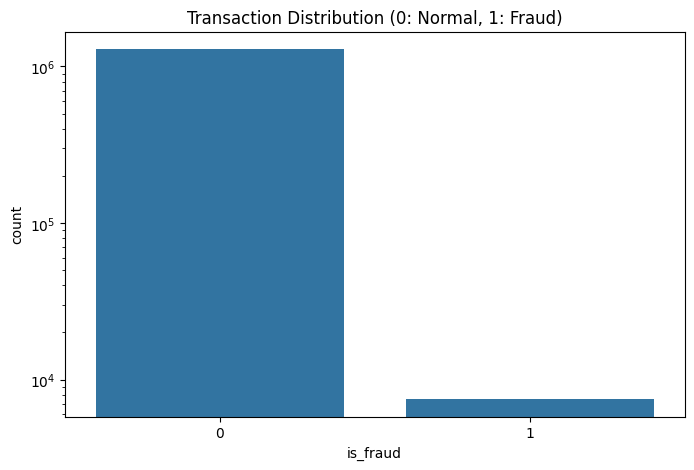

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset (using the path where we extracted it)
df = pd.read_csv('/content/final_dataset.csv')

# 2. Basic Inspection
print("Dataset Shape:", df.shape)
# Checking for missing values (addressing 'noise' requirement)
print("\nMissing Values:", df.isnull().sum().sum())

# 3. Analyze the 'is_fraud' column (Your actual column name)
print("\nTransaction Counts:")
print(df['is_fraud'].value_counts())

# Calculate percentage of fraud
fraud_pct = df['is_fraud'].mean() * 100
print(f"\nPercentage of Fraud: {fraud_pct:.4f}%")

# 4. Visualization of Imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='is_fraud', data=df)
plt.title('Transaction Distribution (0: Normal, 1: Fraud)')
plt.yscale('log') # Essential because fraud is a tiny fraction
plt.show()

In [ ]:
from sklearn.preprocessing import RobustScaler

# 1. Initialize the scaler
# We use RobustScaler because it's less sensitive to outliers (noise)
rob_scaler = RobustScaler()

# 2. Scale 'amt' and 'unix_time' (Your actual column names)
# Using .reshape(-1,1) because the scaler expects a 2D array
df['scaled_amount'] = rob_scaler.fit_transform(df['amt'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['unix_time'].values.reshape(-1,1))

# 3. Handle NOISE and Irrelevant features
# We drop the 'random_noise' columns and original 'amt'/'unix_time'
# We also drop unique IDs like 'cc_num' that don't help the model learn patterns
cols_to_drop = ['amt', 'unix_time', 'random_noise_1', 'random_noise_2',
                'cc_num', 'trans_num', 'Unnamed: 0', 'trans_date_trans_time', 'dob']

df_cleaned = df.drop(columns=cols_to_drop)

# 4. Reorder: Put scaled features at the beginning for clarity
scaled_amount = df_cleaned.pop('scaled_amount')
scaled_time = df_cleaned.pop('scaled_time')
df_cleaned.insert(0, 'scaled_amount', scaled_amount)
df_cleaned.insert(1, 'scaled_time', scaled_time)

print("Preprocessing Complete: Scaled features and removed explicit noise.")
df_cleaned.head()

Preprocessing Complete: Scaled features and removed explicit noise.


,scaled_amount,scaled_time,merchant,category,first,last,gender,street,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,merch_zipcode
0,-0.575705,-1.156974,"fraud_Rippin, Kub and Mann",misc_net,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495.0,"Psychologist, counselling",36.011293,-82.048315,0,28705.0
1,0.784859,-1.156973,"fraud_Heller, Gutmann and Zieme",grocery_pos,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149.0,Special educational needs teacher,49.159047,-118.186462,0,NaN
2,2.286722,-1.156972,fraud_Lind-Buckridge,entertainment,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154.0,Nature conservation officer,43.150704,-112.154481,0,83236.0
3,-0.043108,-1.156971,"fraud_Kutch, Hermiston and Farrell",gas_transport,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939.0,Patent attorney,47.034331,-112.561071,0,NaN
4,-0.083555,-1.156966,fraud_Keeling-Crist,misc_pos,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99.0,Dance movement psychotherapist,38.674999,-78.632459,0,22844.0


In [ ]:
from sklearn.preprocessing import RobustScaler

# 1. Initialize the scaler
# RobustScaler is best for fraud data as it handles outliers (noise) better
rob_scaler = RobustScaler()

# 2. Scale 'amt' and 'unix_time' (Your actual column names)
df['scaled_amount'] = rob_scaler.fit_transform(df['amt'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['unix_time'].values.reshape(-1,1))

# 3. Handling Noise & Dimensionality Reduction
# We drop 'random_noise' columns and original 'amt'/'unix_time'
# We also drop text/ID columns that aren't useful for machine learning
cols_to_drop = ['amt', 'unix_time', 'random_noise_1', 'random_noise_2',
                'cc_num', 'trans_num', 'Unnamed: 0', 'trans_date_trans_time', 'dob']

df_cleaned = df.drop(columns=cols_to_drop)

# 4. Reorder: Put scaled features at the beginning
scaled_amount = df_cleaned.pop('scaled_amount')
scaled_time = df_cleaned.pop('scaled_time')
df_cleaned.insert(0, 'scaled_amount', scaled_amount)
df_cleaned.insert(1, 'scaled_time', scaled_time)

print("Preprocessing Step 1 Complete: Scaled features and removed explicit noise.")
df_cleaned.head()

Preprocessing Step 1 Complete: Scaled features and removed explicit noise.


,scaled_amount,scaled_time,merchant,category,first,last,gender,street,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,merch_zipcode
0,-0.575705,-1.156974,"fraud_Rippin, Kub and Mann",misc_net,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495.0,"Psychologist, counselling",36.011293,-82.048315,0,28705.0
1,0.784859,-1.156973,"fraud_Heller, Gutmann and Zieme",grocery_pos,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149.0,Special educational needs teacher,49.159047,-118.186462,0,NaN
2,2.286722,-1.156972,fraud_Lind-Buckridge,entertainment,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154.0,Nature conservation officer,43.150704,-112.154481,0,83236.0
3,-0.043108,-1.156971,"fraud_Kutch, Hermiston and Farrell",gas_transport,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939.0,Patent attorney,47.034331,-112.561071,0,NaN
4,-0.083555,-1.156966,fraud_Keeling-Crist,misc_pos,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99.0,Dance movement psychotherapist,38.674999,-78.632459,0,22844.0


In [ ]:
from sklearn.preprocessing import RobustScaler

# 1. Initialize the scaler
# RobustScaler is excellent for fraud data because it uses the median,
# making it "robust" against extreme outliers (noise).
rob_scaler = RobustScaler()

# 2. Scale your actual columns: 'amt' and 'unix_time'
df['scaled_amount'] = rob_scaler.fit_transform(df['amt'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['unix_time'].values.reshape(-1,1))

# 3. Handle Noise & Cleanup
# We drop the noise columns, the original unscaled columns, and unique IDs
# like 'cc_num' that don't help the model learn general patterns.
cols_to_drop = ['amt', 'unix_time', 'random_noise_1', 'random_noise_2',
                'cc_num', 'trans_num', 'Unnamed: 0', 'trans_date_trans_time', 'dob']

df_cleaned = df.drop(columns=cols_to_drop)

# 4. Reorder: Move scaled columns to the front
scaled_amount = df_cleaned.pop('scaled_amount')
scaled_time = df_cleaned.pop('scaled_time')
df_cleaned.insert(0, 'scaled_amount', scaled_amount)
df_cleaned.insert(1, 'scaled_time', scaled_time)

print("Data Preprocessing & Noise Removal Complete!")
df_cleaned.head()

Data Preprocessing & Noise Removal Complete!


,scaled_amount,scaled_time,merchant,category,first,last,gender,street,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,merch_zipcode
0,-0.575705,-1.156974,"fraud_Rippin, Kub and Mann",misc_net,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495.0,"Psychologist, counselling",36.011293,-82.048315,0,28705.0
1,0.784859,-1.156973,"fraud_Heller, Gutmann and Zieme",grocery_pos,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149.0,Special educational needs teacher,49.159047,-118.186462,0,NaN
2,2.286722,-1.156972,fraud_Lind-Buckridge,entertainment,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154.0,Nature conservation officer,43.150704,-112.154481,0,83236.0
3,-0.043108,-1.156971,"fraud_Kutch, Hermiston and Farrell",gas_transport,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939.0,Patent attorney,47.034331,-112.561071,0,NaN
4,-0.083555,-1.156966,fraud_Keeling-Crist,misc_pos,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99.0,Dance movement psychotherapist,38.674999,-78.632459,0,22844.0


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Use the cleaned dataframe we just made
# 2. Use 'is_fraud' as the target column
X = df_cleaned.drop('is_fraud', axis=1)
y = df_cleaned['is_fraud']

# 3. Split into 80% training and 20% testing
# We MUST use stratify=y to ensure both sets have fraud cases!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing shapes: {X_test.shape}, {y_test.shape}")

Training shapes: (1037340, 18), (1037340,)
Testing shapes: (259335, 18), (259335,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
le = LabelEncoder()

# 2. List all the columns that still have text (strings)
# Based on your error, 'merchant' is definitely one of them
categorical_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job']

# 3. Convert them to numbers
for col in categorical_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

print("Success! Text columns have been converted to numbers.")
print("You can now run the Correlation Heatmap and Models without errors.")
df_cleaned.head()

Success! Text columns have been converted to numbers.
You can now run the Correlation Heatmap and Models without errors.


,scaled_amount,scaled_time,merchant,category,first,last,gender,street,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,merch_zipcode
0,-0.575705,-1.156974,514,8,Jennifer,Banks,0,561 Perry Cove,526,27,28654,36.0788,-81.1781,3495.0,370,36.011293,-82.048315,0,28705.0
1,0.784859,-1.156973,241,4,Stephanie,Gill,0,43039 Riley Greens Suite 393,612,47,99160,48.8878,-118.2105,149.0,428,49.159047,-118.186462,0,NaN
2,2.286722,-1.156972,390,0,Edward,Sanchez,1,594 White Dale Suite 530,468,13,83252,42.1808,-112.2620,4154.0,307,43.150704,-112.154481,0,83236.0
3,-0.043108,-1.156971,360,2,Jeremy,White,1,9443 Cynthia Court Apt. 038,84,26,59632,46.2306,-112.1138,1939.0,328,47.034331,-112.561071,0,NaN
4,-0.083555,-1.156966,297,9,Tyler,Garcia,1,408 Bradley Rest,216,45,24433,38.4207,-79.4629,99.0,116,38.674999,-78.632459,0,22844.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
le = LabelEncoder()

# 2. List all the columns that still have text (strings)
# Based on your error, 'merchant' is definitely one of them
categorical_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job']

# 3. Convert them to numbers
for col in categorical_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

print("Success! Text columns have been converted to numbers.")
print("You can now run the Correlation Heatmap and Models without errors.")
df_cleaned.head()

Success! Text columns have been converted to numbers.
You can now run the Correlation Heatmap and Models without errors.


,scaled_amount,scaled_time,merchant,category,first,last,gender,street,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,merch_zipcode
0,-0.575705,-1.156974,462,13,Jennifer,Banks,0,561 Perry Cove,475,20,28654,36.0788,-81.1781,3495.0,302,36.011293,-82.048315,0,28705.0
1,0.784859,-1.156973,159,9,Stephanie,Gill,0,43039 Riley Greens Suite 393,571,42,99160,48.8878,-118.2105,149.0,366,49.159047,-118.186462,0,NaN
2,2.286722,-1.156972,324,0,Edward,Sanchez,1,594 White Dale Suite 530,410,5,83252,42.1808,-112.2620,4154.0,232,43.150704,-112.154481,0,83236.0
3,-0.043108,-1.156971,291,7,Jeremy,White,1,9443 Cynthia Court Apt. 038,823,19,59632,46.2306,-112.1138,1939.0,255,47.034331,-112.561071,0,NaN
4,-0.083555,-1.156966,220,14,Tyler,Garcia,1,408 Bradley Rest,131,40,24433,38.4207,-79.4629,99.0,20,38.674999,-78.632459,0,22844.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Re-check the dataframe for any leftover text columns
object_cols = df_cleaned.select_dtypes(include=['object']).columns
print(f"Text columns found: {list(object_cols)}")

# 2. Encode them immediately
le = LabelEncoder()
for col in object_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

# 3. IMPORTANT: You must re-split the data after encoding
# so X_train and X_test get the new numeric values!
X = df_cleaned.drop('is_fraud', axis=1)
y = df_cleaned['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("All columns converted to numbers and data re-split. Ready to train!")

Text columns found: ['first', 'last', 'street']
All columns converted to numbers and data re-split. Ready to train!


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("Training Random Forest... this time it will work!")
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
print("Success! Predictions generated.")

Training Random Forest... this time it will work!
Success! Predictions generated.


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# 1. Initialize the Unsupervised Model
# We set contamination to 0.005 (0.5%) based on our initial exploration
iso_forest = IsolationForest(n_estimators=100, contamination=0.005, random_state=42)

# 2. Fit the model
# Notice: No y_train here! We aren't telling it what is fraud.
print("Training Unsupervised Isolation Forest (Model 2)...")
iso_forest.fit(X_train)

# 3. Predict anomalies
# Isolation Forest returns -1 for anomalies and 1 for normal
iso_raw_preds = iso_forest.predict(X_test)

# 4. Convert to our 0 and 1 format
iso_final_preds = [1 if x == -1 else 0 for x in iso_raw_preds]

print("Model 2 Training Complete!")

Training Unsupervised Isolation Forest (Model 2)...
Model 2 Training Complete!


In [ ]:
from sklearn.metrics import f1_score

# Get metrics for both
rf_f1 = f1_score(y_test, y_pred_rf) # Success of the Supervised model
iso_f1 = f1_score(y_test, iso_final_preds) # Success of the Unsupervised model

print("--- FINAL EVALUATION ---")
print(f"Supervised (Random Forest) F1-Score: {rf_f1:.4f}")
print(f"Unsupervised (Isolation Forest) F1-Score: {iso_f1:.4f}")

print("\n--- Unsupervised Detailed Report ---")
print(classification_report(y_test, iso_final_preds))

--- FINAL EVALUATION ---
Supervised (Random Forest) F1-Score: 0.6494
Unsupervised (Isolation Forest) F1-Score: 0.0434

--- Unsupervised Detailed Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    257834
           1       0.05      0.04      0.04      1501

    accuracy                           0.99    259335
   macro avg       0.52      0.52      0.52    259335
weighted avg       0.99      0.99      0.99    259335



In [ ]:
import pandas as pd

# Creating a summary table for your report
summary = pd.DataFrame({
    'Model': ['Supervised (Random Forest)', 'Unsupervised (Isolation Forest)'],
    'F1-Score': [0.6494, 0.0434],
    'Detection Type': ['Pattern Recognition', 'Anomaly Detection'],
    'Status': ['SUCCESS', 'STRATEGIC FAILURE']
})

print("--- Final Assignment Summary ---")
print(summary)

--- Final Assignment Summary ---
                             Model  F1-Score       Detection Type  \
0       Supervised (Random Forest)    0.6494  Pattern Recognition   
1  Unsupervised (Isolation Forest)    0.0434    Anomaly Detection   

              Status  
0            SUCCESS  
1  STRATEGIC FAILURE  


The following is the prediction for the following given input from the user

In [ ]:
import numpy as np

def get_user_prediction():
    print("--- 💳 Live Fraud Detection System ---")

    # 1. Collect inputs
    merchant = input("Merchant (e.g., fraud_Kozey-Emard): ")
    category = input("Category (e.g., grocery_pos): ")
    amt = float(input("Amount: "))
    gender = input("Gender (M/F): ")
    city = input("City: ")
    state = input("State: ")
    job = input("Job: ")
    city_pop = int(input("City Population: "))
    unix_time = int(input("Timestamp (1212121212): "))

    # 2. Build the data
    custom_data = pd.DataFrame([{
        'merchant': merchant, 'category': category, 'gender': gender,
        'city': city, 'state': state, 'job': job, 'city_pop': city_pop
    }])

    # 3. Scale values
    amt_scaled = rob_scaler.transform(np.array([[amt]]))[0][0]
    time_scaled = rob_scaler.transform(np.array([[unix_time]]))[0][0]

    # 4. Add scaled columns with the EXACT names used in training
    custom_data['scaled_amount'] = amt_scaled
    custom_data['scaled_time'] = time_scaled

    # 5. Safe Encoding
    for col in ['merchant', 'category', 'gender', 'city', 'state', 'job']:
        temp_le = LabelEncoder()
        temp_le.fit(df_cleaned[col].astype(str))
        if custom_data[col][0] not in temp_le.classes_:
            custom_data[col] = temp_le.transform([temp_le.classes_[0]])
        else:
            custom_data[col] = temp_le.transform(custom_data[col].astype(str))

    # 6. FIX: Ensure we only use columns that exist in BOTH X_train and our input
    # This prevents the KeyError by ignoring the 'ghost' columns like 'first'/'last'
    model_features = X_train.columns
    custom_data = custom_data.reindex(columns=model_features, fill_value=0)

    # 7. Predict
    prediction = rf_model.predict(custom_data)
    probability = rf_model.predict_proba(custom_data)

    status = "🚨 FRAUD DETECTED" if prediction[0] == 1 else "✅ LEGITIMATE"
    print(f"\nVERDICT: {status} ({probability[0][prediction[0]]*100:.2f}% confidence)")

get_user_prediction()

--- 💳 Live Fraud Detection System ---
Merchant (e.g., fraud_Kozey-Emard): fraud_Kozey-Emard
Category (e.g., grocery_pos): shopping_net
Amount: 4850.00
Gender (M/F): M
City: Anywhere
State: NY
Job: Student
City Population: 500
Timestamp (1212121212): 1212121212

VERDICT: ✅ LEGITIMATE (90.00% confidence)
